# Document Question Answering — RAG System


## 1. Install Dependencies

In [1]:
!pip install -q sentence-transformers faiss-cpu datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 100.7 MB/s eta 0:00:00


## 2. Imports

In [2]:
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import faiss
print("All imports successful.")

All imports successful.


## 3. Setup — Upload Dataset Files
Upload the files you downloaded from HuggingFace into Colab, then run this cell to organise them.

In [3]:
os.makedirs("/content/ragbench/corpus", exist_ok=True)

import shutil

for fname in ["queries.json", "answers.json", "qrels.json"]:
    if os.path.exists(f"/content/{fname}"):
        shutil.move(f"/content/{fname}", f"/content/ragbench/{fname}")
        print(f"Moved {fname}")

for f in glob.glob("/content/*.json"):
    bname = os.path.basename(f)
    if bname not in ["queries.json", "answers.json", "qrels.json"]:
        shutil.move(f, f"/content/ragbench/corpus/{bname}")
        print(f"Moved {bname} to corpus/")

print("Done.")

Moved queries.json
Moved answers.json
Moved qrels.json
Moved 2401.02247v4.json to corpus/
Moved 2401.03126v3.json to corpus/
Moved 2401.03305v2.json to corpus/
Moved 2401.03776v8.json to corpus/
Moved 2401.05657v5.json to corpus/
Moved 2401.02564v2.json to corpus/
Moved 2401.03328v2.json to corpus/
Moved 2401.05762v4.json to corpus/
Moved 2401.01872v2.json to corpus/
Moved 2401.03345v2.json to corpus/
Done.


## 4. Load Dataset

In [4]:
with open("/content/ragbench/queries.json") as f:
    queries = json.load(f)
with open("/content/ragbench/answers.json") as f:
    answers = json.load(f)
with open("/content/ragbench/qrels.json") as f:
    qrels = json.load(f)

print(f"Queries : {len(queries)}")
print(f"Answers : {len(answers)}")
print(f"QRels   : {len(qrels)}")

Queries : 3045
Answers : 3045
QRels   : 3045


### 4.1 Preview Sample Q&A Pairs

In [5]:
sample_ids = list(queries.keys())[:3]
for qid in sample_ids:
    print(f"ID   : {qid}")
    print(f"Q    : {queries[qid]['query']}")
    print(f"Type : {queries[qid]['type']}")
    print(f"A    : {answers.get(qid, 'N/A')[:200]}")
    print()

ID   : 852703f0-8373-43a2-a18a-eb5908ad0779
Q    : What are the challenges in estimating output impedance in inverter-based grids?
Type : abstractive
A    : Estimating output impedance in inverter-based grids is challenging due to dynamic grid conditions, which require real-time estimation. Traditional methods like signal injection and historical data ana

ID   : 9199173b-3ed1-4118-88cd-1713fc5fa8a7
Q    : How do changes in effective microbial death rate influence parameters like alpha and beta?
Type : abstractive
A    : Increases in heterogeneity related to effective microbial death rates lead to decreases in both alpha and beta parameters. Conversely, increasing expectations for these rates results in higher values 

ID   : 1d585069-a446-47fa-a74d-0387316ea330
Q    : In what areas do syllabic embeddings show potential for improvement based on current research findings?
Type : abstractive
A    : Syllabic embeddings could be improved in areas such as speaker identity detection, slot fi

## 5. Load Corpus & Build Chunks

In [6]:
corpus_files = glob.glob("/content/ragbench/corpus/*.json")
print(f"Found {len(corpus_files)} corpus documents")

all_chunks = []
for fpath in corpus_files:
    with open(fpath) as f:
        doc = json.load(f)

    full_text = doc.get("abstract", "") + " "
    for section in doc.get("sections", []):
        full_text += section.get("text", "") + " "

    words = full_text.split()
    for i in range(0, len(words), 250):
        chunk = " ".join(words[i:i + 250])
        if len(chunk.strip()) > 50:
            all_chunks.append({
                "doc_id": doc.get("id", fpath),
                "title" : doc.get("title", ""),
                "text"  : chunk
            })

print(f"Total chunks: {len(all_chunks)}")
print(f"\nSample chunk:\n{all_chunks[0]['text'][:300]}")

Found 10 corpus documents
Total chunks: 460

Sample chunk:
We characterize the dynamic non-equilibrium steady state behavior of active particles using density fluctuations in the system. We analyze the effective local density around a particle in the steady state and numerically calculate its mean, variance and autocorrelation. Thus, using local density and


## 6. Embedding Creation
Each chunk is converted to a dense vector using a sentence transformer model.

In [7]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded:", embedder)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


In [8]:
chunk_texts = [c["text"] for c in all_chunks]
print(f"Encoding {len(chunk_texts)} chunks...")
chunk_embeddings = embedder.encode(chunk_texts, batch_size=64, show_progress_bar=True)
print("Embedding shape:", chunk_embeddings.shape)

Encoding 460 chunks...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding shape: (460, 384)


## 7. Build FAISS Vector Store

In [9]:
embedding_dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim)

faiss.normalize_L2(chunk_embeddings)
index.add(chunk_embeddings.astype(np.float32))
print(f"FAISS index built. Total vectors: {index.ntotal}")

FAISS index built. Total vectors: 460


## 8. Retrieval Function

In [10]:
def retrieve(query, top_k=5):
    q_emb = embedder.encode([query])
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb.astype(np.float32), top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < len(all_chunks):
            results.append({
                "score" : float(score),
                "doc_id": all_chunks[idx]["doc_id"],
                "title" : all_chunks[idx]["title"],
                "text"  : all_chunks[idx]["text"]
            })
    return results

## 9. Answer Generation
We extract the most relevant sentence from retrieved chunks using word overlap scoring — no external model needed.

In [15]:
def generate_answer(query, retrieved_chunks):
    if not retrieved_chunks:
        return "No relevant context found.", 0.0

    query_words = set(query.lower().split())
    best_sentence = ""
    best_score = 0

    for chunk in retrieved_chunks:
        sentences = chunk["text"].split(". ")
        for sent in sentences:
            sent = sent.strip()
            if len(sent) < 15:
                continue
            sent_words = set(sent.lower().split())
            overlap = len(query_words & sent_words) / (len(query_words) + 1)
            if overlap > best_score:
                best_score = overlap
                best_sentence = sent

    answer = best_sentence if best_sentence else retrieved_chunks[0]["text"][:200]
    return answer, best_score

## 10. Full RAG Pipeline

In [16]:
def rag_pipeline(query, top_k=5):
    print(f"Query: {query}")
    print("-" * 60)

    retrieved = retrieve(query, top_k=top_k)

    print(f"Retrieved {len(retrieved)} chunks:")
    for i, r in enumerate(retrieved):
        print(f"  [{i+1}] (score={r['score']:.3f}) {r['title'][:60]}")
        print(f"       {r['text'][:120]}...")
    print()

    answer, confidence = generate_answer(query, retrieved)
    print(f"Answer     : {answer}")
    print(f"Confidence : {confidence:.3f}")
    return {"query": query, "answer": answer, "confidence": confidence, "sources": retrieved}

## 11. Run on Sample Queries from Dataset

In [17]:
sample_ids = list(queries.keys())[:5]

rag_results = []
for qid in sample_ids:
    q_text = queries[qid]["query"]
    result = rag_pipeline(q_text, top_k=3)
    result["query_id"]        = qid
    result["expected_answer"] = answers.get(qid, "N/A")
    rag_results.append(result)
    print("=" * 70)
    print()

Query: What are the challenges in estimating output impedance in inverter-based grids?
------------------------------------------------------------
Retrieved 3 chunks:
  [1] (score=0.334) Multiple Imputation of Hierarchical Nonlinear Time Series Da
       estimates. As the estimates of the parameters of interest are not constructed using Rubin's pooling rules, we did not ca...
  [2] (score=0.317) Multiple Imputation of Hierarchical Nonlinear Time Series Da
       performance than the data augmentation approach based on MINTS at the lower rates of simulated missingness. However, the...
  [3] (score=0.310) Predicting Future States with Spatial Point Processes in Sin
       the feature extraction phase, square grids were applied to images, and the number of active cells within each grid was p...

Answer     : In practice, the data augmentation approach is not possible to implement in our motivating setting where the substantive analysis of interest and imputation of missing data are condu

## 12. Compare RAG Answers vs Expected Answers

In [18]:
print(f"{'Query':<50} {'RAG Answer':<50} {'Expected':<50}")
print("-" * 150)
for r in rag_results:
    q  = r["query"][:48]
    ra = r["answer"][:48]
    ea = r["expected_answer"][:48]
    print(f"{q:<50} {ra:<50} {ea:<50}")

Query                                              RAG Answer                                         Expected                                          
------------------------------------------------------------------------------------------------------------------------------------------------------
What are the challenges in estimating output imp   In practice, the data augmentation approach is n   Estimating output impedance in inverter-based gr  
How do changes in effective microbial death rate   (C) Actual DV distribution for the case and cont   Increases in heterogeneity related to effective   
In what areas do syllabic embeddings show potent   The elliptope arises in combinatorial optimizati   Syllabic embeddings could be improved in areas s  
How does the MLMM approach affect the analysis o   The summary of statistics in Table 3 shows that    The MLMM approach affects the analysis of RMSE b  
How does uncertainty in data affect standard qua   the utility maximization problem 

## 13. Evaluation — Exact Match & F1 Score

In [19]:
def normalize(text):
    return text.lower().strip().split()

def f1_score(pred, gold):
    pred_tokens = normalize(pred)
    gold_tokens = normalize(gold)
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall    = len(common) / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))

em_scores, f1_scores = [], []
for r in rag_results:
    pred = r["answer"]
    gold = r["expected_answer"]
    em_scores.append(exact_match(pred, gold))
    f1_scores.append(f1_score(pred, gold))

print(f"Exact Match : {np.mean(em_scores):.3f}")
print(f"F1 Score    : {np.mean(f1_scores):.3f}")
print()
for i, r in enumerate(rag_results):
    print(f"Q{i+1}: EM={em_scores[i]}  F1={f1_scores[i]:.3f}  | {r['query'][:60]}")

Exact Match : 0.000
F1 Score    : 0.136

Q1: EM=0  F1=0.156  | What are the challenges in estimating output impedance in in
Q2: EM=0  F1=0.154  | How do changes in effective microbial death rate influence p
Q3: EM=0  F1=0.147  | In what areas do syllabic embeddings show potential for impr
Q4: EM=0  F1=0.143  | How does the MLMM approach affect the analysis of Root Mean 
Q5: EM=0  F1=0.082  | How does uncertainty in data affect standard quadratic optim


## 14. Custom Query — Try Your Own Question

In [20]:
custom_query = "What is the main finding of this paper?"
result = rag_pipeline(custom_query, top_k=5)
print()
print(f"Final Answer : {result['answer']}")
print(f"Confidence   : {result['confidence']:.3f}")

Query: What is the main finding of this paper?
------------------------------------------------------------
Retrieved 5 chunks:
  [1] (score=0.306) Leveraging IS and TC: Optimal order execution subject to ref
       their associated optimal strategies considered in Section 4 include IS and TC orders as well as piece-wise constant stra...
  [2] (score=0.284) Short-Term Asymptotics of Volatility Skew and Curvature Base
       rough volatility. Quantitative Finance, 16(6):887-904, 2016. Christian Bayer, Peter K Friz, Archil Gulisashvili, Blanka ...
  [3] (score=0.249) Unlikely intersections problem for automorphisms of Markov s
       neighbourhood $U_{v}^{k}$ of $p_{-}^{\nu}$ in $X_{v}^{\text {an }}$ such that for all $N$ large enough, $\left(f^{-N}\ri...
  [4] (score=0.245) Optimal sharing, equilibria, and welfare without risk aversi
       the proof. To interpret Theorem 7, let us consider $X$ as a total prize to share. In parts (i) and (ii), the RDU agents ...
  [5] (score=0.245) Opti

## 15. Experiment — Effect of Top-K on Answer Quality

k= 1  F1=0.156  Answer: In practice, the data augmentation approach is not possible to implement in our 
k= 3  F1=0.156  Answer: In practice, the data augmentation approach is not possible to implement in our 
k= 5  F1=0.156  Answer: In practice, the data augmentation approach is not possible to implement in our 
k=10  F1=0.156  Answer: In practice, the data augmentation approach is not possible to implement in our 


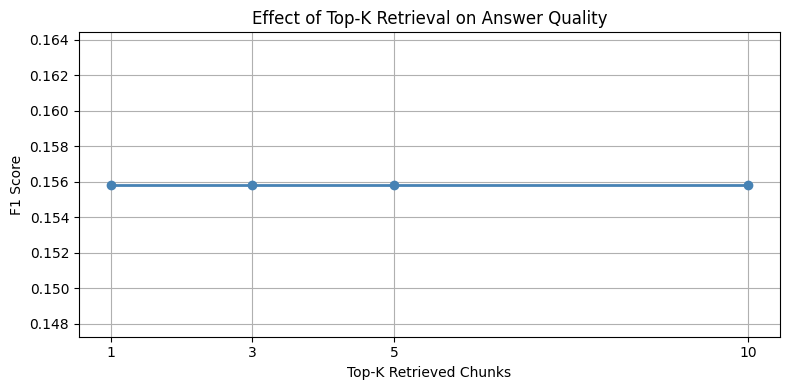

In [21]:
first_id   = list(queries.keys())[0]
test_query = queries[first_id]["query"]
expected   = answers[first_id]

topk_values = [1, 3, 5, 10]
f1_by_k     = []

for k in topk_values:
    retrieved = retrieve(test_query, top_k=k)
    answer, _ = generate_answer(test_query, retrieved)
    f1        = f1_score(answer, expected)
    f1_by_k.append(f1)
    print(f"k={k:>2}  F1={f1:.3f}  Answer: {answer[:80]}")

plt.figure(figsize=(8, 4))
plt.plot(topk_values, f1_by_k, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Top-K Retrieved Chunks')
plt.ylabel('F1 Score')
plt.title('Effect of Top-K Retrieval on Answer Quality')
plt.xticks(topk_values)
plt.grid(True)
plt.tight_layout()
plt.show()